# PyTorch Datasets and DataLoaders — Google Colab Version

This notebook adapts the original local notebook so it runs cleanly in **Google Colab**.

It also adds a few teaching examples inspired by the slide on this topic:

- **map-style datasets** with `__len__()` and `__getitem__()`
- **streaming / iterable datasets** with `__iter__()`
- the difference between **random access** and **sequential flow**
- `random_split(...)` and the meaning of subset indices
- `DataLoader(...)` batching, `shuffle`, and `drop_last`
- a tiny training example that sends batches to the detected **Colab device**

> In Colab, the relevant accelerator is usually **CUDA GPU**.  
> Apple `mps` device logic is not needed in Colab.


In [ ]:
# Cell 1: Imports and Colab-aware runtime setup
import os
import sys
import time
import random
import platform

import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, IterableDataset, DataLoader, random_split, get_worker_info

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

# In Google Colab, the main accelerated option is CUDA.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE_NAME = torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "CPU"

# These DataLoader settings are reasonable defaults for Colab.
PIN_MEMORY = DEVICE.type == "cuda"
NUM_WORKERS = 2 if IN_COLAB else 0

print(f"In Colab:        {IN_COLAB}")
print(f"Python version:  {sys.version.split()[0]}")
print(f"PyTorch version: {torch.__version__}")
print(f"Platform:        {platform.platform()}")
print(f"Device:          {DEVICE} ({DEVICE_NAME})")
print(f"pin_memory:      {PIN_MEMORY}")
print(f"num_workers:     {NUM_WORKERS}")

if IN_COLAB and DEVICE.type == "cpu":
    print("\nTip: Runtime -> Change runtime type -> Hardware accelerator -> GPU")


In Colab:        True
Python version:  3.12.13
PyTorch version: 2.10.0+cpu
Platform:        Linux-6.6.113+-x86_64-with-glibc2.35
Device:          cpu (CPU)
pin_memory:      False
num_workers:     2

Tip: Runtime -> Change runtime type -> Hardware accelerator -> GPU


In [ ]:
# Cell 2: Small device sanity check
x = torch.randn(5, device=DEVICE)
print("Sample tensor on selected device:")
print(x)


Sample tensor on selected device:
tensor([ 0.3367,  0.1288,  0.2345,  0.2303, -1.1229])


## 1. Map-style dataset (`torch.utils.data.Dataset`)

A **map-style dataset** is the familiar PyTorch dataset type for random access.

You typically implement:

- `__len__()` → how many samples exist
- `__getitem__(idx)` → how to fetch one sample by index

This is the dataset type that works naturally with:

- arbitrary indexing such as `dataset[7]`
- `shuffle=True` in `DataLoader`
- train / validation / test splitting


In [ ]:
# Cell 3: A custom map-style dataset
class SquaresDataset(Dataset):
    def __init__(self, n, noise_std=0.25):
        self.n = n
        self.noise_std = noise_std

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        x = torch.tensor(float(idx), dtype=torch.float32)
        noise = torch.randn((), dtype=torch.float32) * self.noise_std
        y = (x + noise) ** 2
        return x, y


In [ ]:
# Cell 4: Random access / arbitrary indexing
square_dataset = SquaresDataset(10)

print(f"Dataset length: {len(square_dataset)}\n")

requested_indices = [3, 0, 7, 2]
for idx in requested_indices:
    x, y = square_dataset[idx]
    print(f"dataset[{idx}] -> x={x.item():.0f}, y={y.item():.3f}")


Dataset length: 10

dataset[3] -> x=3, y=8.723
dataset[0] -> x=0, y=0.305
dataset[7] -> x=7, y=46.792
dataset[2] -> x=2, y=4.475


## 2. Streaming / iterable dataset (`torch.utils.data.IterableDataset`)

A **streaming dataset** is different:

- it implements `__iter__()`
- it yields samples one by one
- it is designed for **sequential flow**, not random indexing

This is useful when data:

- comes from a stream, logs, or a generator
- is too large to store as a normal indexable dataset
- is produced on the fly


In [ ]:
# Cell 5: A custom iterable dataset
class StreamingSquaresDataset(IterableDataset):
    def __init__(self, start=0, end=10):
        self.start = start
        self.end = end

    def __iter__(self):
        idx = self.start
        while idx < self.end:
            x = torch.tensor(float(idx), dtype=torch.float32)
            y = x ** 2
            yield x, y
            idx += 1


In [ ]:
# Cell 6: Sequential one-pass iteration
for x, y in StreamingSquaresDataset(0, 10):
    print(f"x={x.item():.0f}, y={y.item():.0f}")


x=0, y=0
x=1, y=1
x=2, y=4
x=3, y=9
x=4, y=16
x=5, y=25
x=6, y=36
x=7, y=49
x=8, y=64
x=9, y=81


In [ ]:
# Cell 7: What is NOT naturally available for an iterable dataset?
stream_dataset = StreamingSquaresDataset(0, 10)

try:
    print("len(stream_dataset) =", len(stream_dataset))
except Exception as e:
    print("len(...) is unavailable here:", e)

try:
    print(stream_dataset[3])
except Exception as e:
    print("Indexing is unavailable here:", e)

try:
    bad_loader = DataLoader(stream_dataset, batch_size=4, shuffle=True)
except Exception as e:
    print("shuffle=True is not supported for IterableDataset:", e)


len(...) is unavailable here: object of type 'StreamingSquaresDataset' has no len()
Indexing is unavailable here: Subclasses of Dataset should implement __getitem__.
shuffle=True is not supported for IterableDataset: DataLoader with IterableDataset: expected unspecified shuffle option, but got shuffle=True


## 3. Side-by-side summary

**Map-style dataset**
- implements `__len__` and `__getitem__`
- supports arbitrary indexing
- natural fit for `shuffle=True`

**Iterable dataset**
- implements `__iter__`
- sequential / one-pass behavior
- useful when data is generated or streamed


## 4. Train / validation / test split

When you call `random_split(...)`, PyTorch returns **Subset** objects.

Each subset does **not** duplicate the data.  
Instead, it stores a list of indices that point back to the original dataset.


In [ ]:
# Cell 8: random_split with a fixed seed for reproducibility
full_dataset = SquaresDataset(100, noise_std=0.10)

train_size = int(0.70 * len(full_dataset))
valid_size = int(0.20 * len(full_dataset))
test_size = len(full_dataset) - train_size - valid_size

split_generator = torch.Generator().manual_seed(SEED)
train_dataset, valid_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, valid_size, test_size],
    generator=split_generator,
)

print(f"Train size: {len(train_dataset)}")
print(f"Valid size: {len(valid_dataset)}")
print(f"Test size:  {len(test_dataset)}")


Train size: 70
Valid size: 20
Test size:  10


In [ ]:
# Cell 9: Inspect the subset indices chosen by random_split
print("Type returned by random_split:", type(train_dataset))
print("\nFirst 15 train indices:")
print(train_dataset.indices[:15])

print("\nFirst 15 validation indices:")
print(valid_dataset.indices[:15])

print("\nAll test indices:")
print(test_dataset.indices)


Type returned by random_split: <class 'torch.utils.data.dataset.Subset'>

First 15 train indices:
[42, 96, 62, 98, 46, 95, 60, 24, 78, 16, 68, 70, 11, 13, 97]

First 15 validation indices:
[47, 41, 29, 80, 57, 84, 36, 17, 34, 72, 2, 91, 8, 53, 30]

All test indices:
[14, 55, 0, 64, 77, 39, 25, 92, 49, 28]


## 5. DataLoader: turning samples into mini-batches

`DataLoader(...)` takes a dataset and handles batching for training.

Important arguments here:

- `batch_size`
- `shuffle`
- `drop_last`
- `num_workers`
- `pin_memory` (mostly relevant when using CUDA GPU)


In [ ]:
# Cell 10: A helper to inspect DataLoader batches
def show_batches(loader, max_batches=3, title=None):
    if title:
        print(title)
    for batch_idx, (x, y) in enumerate(loader):
        print(f"Batch {batch_idx + 1}:")
        print("  x =", x)
        print("  y =", y)
        if batch_idx + 1 >= max_batches:
            break


In [ ]:
# Cell 11: shuffle=True and drop_last=True
train_loader_drop = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

show_batches(train_loader_drop, max_batches=3, title="Batches with drop_last=True")


Batches with drop_last=True
Batch 1:
  x = tensor([78., 33., 96., 32.])
  y = tensor([6083.9072, 1086.3188, 9208.4141, 1024.7526])
Batch 2:
  x = tensor([86., 73., 43., 71.])
  y = tensor([7406.1094, 5314.3804, 1851.0936, 5018.3809])
Batch 3:
  x = tensor([18., 89., 68., 93.])
  y = tensor([ 325.7516, 7913.4482, 4632.6523, 8642.7686])


In [ ]:
# Cell 12: shuffle=True and drop_last=False
train_loader_keep = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

show_batches(train_loader_keep, max_batches=3, title="Batches with drop_last=False")


Batches with drop_last=False
Batch 1:
  x = tensor([37., 44., 70., 24.])
  y = tensor([1366.0869, 1930.2115, 4931.8418,  570.7200])
Batch 2:
  x = tensor([ 4., 87., 48., 19.])
  y = tensor([  14.3571, 7580.1299, 2315.9385,  356.3943])
Batch 3:
  x = tensor([31., 20., 10., 12.])
  y = tensor([966.3809, 394.9880,  97.6125, 143.7943])


In [ ]:
# Cell 13: Iterable dataset + DataLoader
stream_loader = DataLoader(
    StreamingSquaresDataset(0, 10),
    batch_size=4,
    num_workers=0,   # keep this simple and deterministic first
)

for x, y in stream_loader:
    print("x =", x, " | y =", y)


x = tensor([0., 1., 2., 3.])  | y = tensor([0., 1., 4., 9.])
x = tensor([4., 5., 6., 7.])  | y = tensor([16., 25., 36., 49.])
x = tensor([8., 9.])  | y = tensor([64., 81.])


## 6. Optional advanced example: sharding an iterable dataset across workers

The slide mentions that iterable datasets can use **sharding**.

That means:
- worker 0 handles some elements
- worker 1 handles other elements
- together they cover the stream without duplicating work

This is especially useful for large streams and generated data.


In [ ]:
# Cell 14: Worker-aware iterable dataset (optional advanced example)
class ShardedStreamingSquares(IterableDataset):
    def __init__(self, start=0, end=20):
        self.start = start
        self.end = end

    def __iter__(self):
        worker_info = get_worker_info()

        if worker_info is None:
            iter_start = self.start
            step = 1
        else:
            iter_start = self.start + worker_info.id
            step = worker_info.num_workers

        for idx in range(iter_start, self.end, step):
            x = torch.tensor(float(idx), dtype=torch.float32)
            y = x ** 2
            yield x, y


In [ ]:
# Cell 15: Optional demonstration of sharding with 2 workers
sharded_loader = DataLoader(
    ShardedStreamingSquares(0, 12),
    batch_size=3,
    num_workers=2,
)

for x, y in sharded_loader:
    print("x =", x, " | y =", y)


x = tensor([0., 2., 4.])  | y = tensor([ 0.,  4., 16.])
x = tensor([1., 3., 5.])  | y = tensor([ 1.,  9., 25.])
x = tensor([ 6.,  8., 10.])  | y = tensor([ 36.,  64., 100.])
x = tensor([ 7.,  9., 11.])  | y = tensor([ 49.,  81., 121.])


## 7. Tiny training example using `DataLoader` batches on the selected device

Below, we fit a tiny quadratic model:

\[
\hat{y} = a x^2 + b x + c
\]

This is not meant to be a sophisticated model.  
It is just a compact way to show that:

- batches come from the `DataLoader`
- each batch is moved to the detected **Colab device**
- optimization gradually learns parameters close to the square function


In [ ]:
# Cell 16: Tiny batch training example
params = torch.randn(3, device=DEVICE, dtype=torch.float32, requires_grad=True)

def model(x):
    return params[0] * x**2 + params[1] * x + params[2]

criterion = torch.nn.L1Loss()  # MAE / L1 loss
optimizer = torch.optim.AdamW([params], lr=0.01)

losses = []

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

for epoch in range(300):
    epoch_loss = 0.0

    for x, y in train_loader:
        x = x.to(DEVICE, non_blocking=PIN_MEMORY).float()
        y = y.to(DEVICE, non_blocking=PIN_MEMORY).float()

        y_pred = model(x)
        loss = criterion(y_pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    mean_epoch_loss = epoch_loss / len(train_loader)
    losses.append(mean_epoch_loss)

    if (epoch + 1) % 50 == 0:
        print(
            f"Epoch {epoch + 1:>3} | "
            f"loss={mean_epoch_loss:.4f} | "
            f"a={params[0].item():.4f}, b={params[1].item():.4f}, c={params[2].item():.4f}"
        )

print("\nFinal learned parameters:", params.detach().cpu().numpy())


Epoch  50 | loss=13.8271 | a=0.9887, b=1.0018, c=-1.0926
Epoch 100 | loss=9.8641 | a=0.9986, b=0.2286, c=-2.6570
Epoch 150 | loss=11.9488 | a=0.9943, b=0.1406, c=-2.1670
Epoch 200 | loss=11.4406 | a=0.9998, b=0.1495, c=-1.5305
Epoch 250 | loss=14.0782 | a=0.9963, b=0.0813, c=-1.1484
Epoch 300 | loss=12.5636 | a=1.0032, b=0.0634, c=-0.8702

Final learned parameters: [ 1.0031766  0.0634485 -0.8701841]


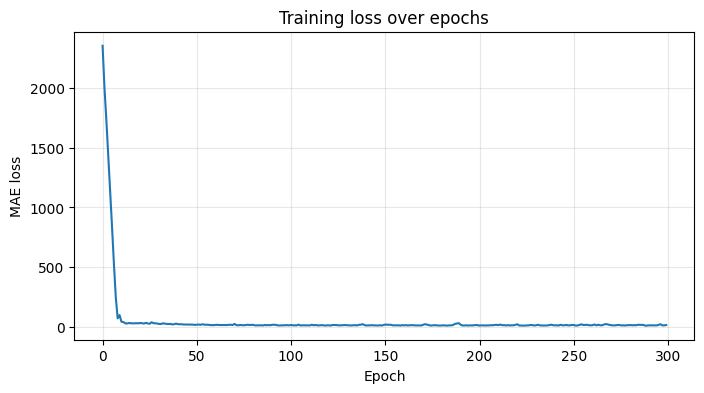

In [ ]:
# Cell 17: Plot the training loss
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MAE loss")
plt.title("Training loss over epochs")
plt.grid(True, alpha=0.3)
plt.show()


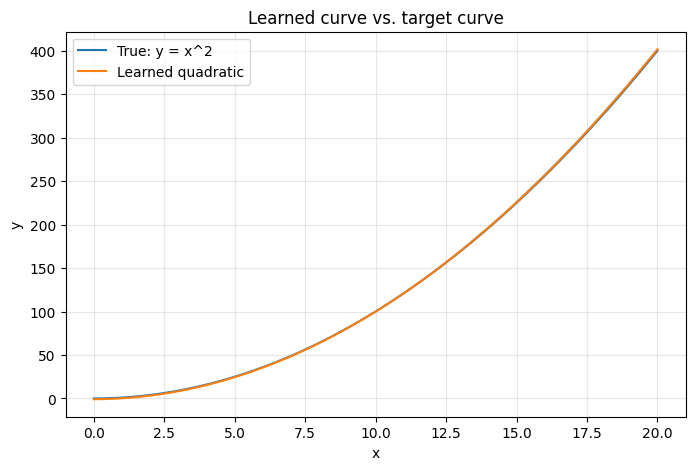

In [ ]:
# Cell 18: Compare the learned curve to the ideal y = x^2 curve
x_plot = torch.linspace(0, 20, 200, device=DEVICE)

with torch.no_grad():
    y_pred_plot = model(x_plot).cpu()

y_true_plot = x_plot.cpu() ** 2

plt.figure(figsize=(8, 5))
plt.plot(x_plot.cpu(), y_true_plot, label="True: y = x^2")
plt.plot(x_plot.cpu(), y_pred_plot, label="Learned quadratic")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Learned curve vs. target curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 8. Main takeaway

Use a **map-style dataset** when:
- the data is indexable
- you want random access
- you want standard shuffling behavior

Use an **iterable dataset** when:
- the data is streamed or generated
- a one-pass sequential flow makes more sense
- the full dataset may be too large to index cleanly
